# Pharmacy Voronoi (clustered sites) + OSRM drive-time layer

**Sites:** Active pharmacies from [`pharmacies_active.json`](../data/pharmacies_active.json), ordered like [`osrm_address_pharmacy_matrix_meta.json`](../data/osrm_address_pharmacy_matrix_meta.json) / [`osrm_address_pharmacy_duration_sec.npy`](../data/osrm_address_pharmacy_duration_sec.npy).

**Clustering:** Pharmacies within **`CLUSTER_MILES`** of another (Euclidean **UTM meters**, single linkage) share one **representative point** (mean easting/northing of the group).

**Tessellation:** **Planar Voronoi** of those seeds in UTM, clipped to [`counties_five_vt.geojson`](../data/counties_five_vt.geojson). Cells are drawn **outline only** (transparent fill) so they stay visible over the heat layer.

**Toggle layer — OSRM “heatmap”:** Interpolated raster (same idea as [`03-osrm_access.ipynb`](03-osrm_access.ipynb)): **best one-way drive time** (minutes) at each sampled address, `scipy.griddata` to a grid, masked to the study region, as a semi-transparent **ImageOverlay**. Turn it on/off in the layer control.

**Tooltips** on Voronoi cells still report **median** best OSRM time among addresses in that cell (for quick comparison to the raster).

pharmacies 224 → 87 clusters (≤1.5 mi); 26 Voronoi cells; 86,654 address–cell pairs
Saved ../data/pharmacy_voronoi_osrm.html



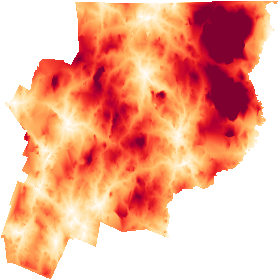

In [3]:
from __future__ import annotations

import json
from pathlib import Path

import branca.colormap as cm
import folium
import geopandas as gpd
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import shapely
from matplotlib import colormaps as mpl_cmaps
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.interpolate import griddata
from scipy.spatial.distance import pdist
from shapely.geometry import MultiPoint, Point

DATA_DIR = Path("../data")
PHARM_JSON = DATA_DIR / "pharmacies_active.json"
META_JSON = DATA_DIR / "osrm_address_pharmacy_matrix_meta.json"
DURATION_NPY = DATA_DIR / "osrm_address_pharmacy_duration_sec.npy"
ADDRESSES_CSV = DATA_DIR / "addresses_with_population_weights.csv"
FIVE_COUNTIES = DATA_DIR / "counties_five_vt.geojson"
MAP_HTML = DATA_DIR / "pharmacy_voronoi_osrm.html"

CRS_UTM = "EPSG:32618"
CLUSTER_MILES = 1.5
CLUSTER_METERS = CLUSTER_MILES * 1609.344
TIME_LEGEND_MAX_MIN = 60.0
GRID_RES = 280
HEAT_OVERLAY_OPACITY = 0.55

with META_JSON.open(encoding="utf-8") as f:
    meta = json.load(f)
place_order = meta["pharmacy_place_ids"]
by_id = {r["place_id"]: r for r in json.loads(PHARM_JSON.read_text(encoding="utf-8"))}
rows = [by_id[pid] for pid in place_order]

pharm = gpd.GeoDataFrame(
    rows,
    geometry=gpd.points_from_xy([r["lon"] for r in rows], [r["lat"] for r in rows]),
    crs="EPSG:4326",
).to_crs(CRS_UTM)

xy = np.column_stack([pharm.geometry.x, pharm.geometry.y])
Z = linkage(pdist(xy), method="single")
pharm["cluster"] = fcluster(Z, t=CLUSTER_METERS, criterion="distance")

centroid_rows = []
summaries = {}
for cid, sub in pharm.groupby("cluster"):
    centroid_rows.append(
        {
            "cluster": int(cid),
            "geometry": Point(float(sub.geometry.x.mean()), float(sub.geometry.y.mean())),
            "n_pharmacies": len(sub),
        }
    )
    head = sub.head(6)
    parts = [f"{r['name']} ({r['city']})" for _, r in head.iterrows()]
    suf = "; …" if len(sub) > 6 else ""
    summaries[cid] = "; ".join(parts) + suf

centroids = gpd.GeoDataFrame(centroid_rows, crs=CRS_UTM)
centroids["pharmacy_summary"] = centroids["cluster"].map(summaries)

boundary = gpd.read_file(FIVE_COUNTIES).to_crs(CRS_UTM)
study = boundary.geometry.union_all()
envelope = study.convex_hull.buffer(80_000)

site_xy = np.column_stack([centroids.geometry.x, centroids.geometry.y])
mp = MultiPoint([(float(x), float(y)) for x, y in site_xy])
raw_cells = shapely.voronoi_polygons(mp, extend_to=envelope)
polys = list(raw_cells.geoms)


def polygon_for_site(sx: float, sy: float) -> shapely.geometry.base.BaseGeometry:
    p = Point(sx, sy)
    for poly in polys:
        if poly.contains(p) or poly.buffer(1e-3).contains(p):
            return poly.intersection(study)
    nearest = min(polys, key=lambda po: po.distance(p))
    return nearest.intersection(study)


cell_geoms = []
for _, row in centroids.iterrows():
    g = polygon_for_site(row.geometry.x, row.geometry.y)
    if g.is_empty:
        continue
    cell_geoms.append(
        {
            "cluster": row["cluster"],
            "n_pharmacies": row["n_pharmacies"],
            "pharmacy_summary": row["pharmacy_summary"],
            "geometry": g,
        }
    )

cells = gpd.GeoDataFrame(cell_geoms, crs=CRS_UTM)
cells = cells[cells.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
cells.reset_index(drop=True, inplace=True)

d_matrix = np.load(DURATION_NPY)
addr = pd.read_csv(ADDRESSES_CSV)
if len(addr) != d_matrix.shape[0]:
    raise ValueError("Address count does not match duration matrix rows")
best_min = np.nanmin(d_matrix, axis=1) / 60.0
ok = np.isfinite(best_min)
addr_g = gpd.GeoDataFrame(
    {"best_min": best_min[ok]},
    geometry=gpd.points_from_xy(addr.loc[ok, "lon"], addr.loc[ok, "lat"]),
    crs="EPSG:4326",
).to_crs(CRS_UTM)

joined = addr_g.sjoin(cells, predicate="within", how="inner")
stats = joined.groupby("index_right", sort=False)["best_min"].agg(
    median_min="median", n_addrs="count"
)
cells["median_min"] = stats["median_min"].reindex(cells.index)
cells["n_addrs"] = stats["n_addrs"].reindex(cells.index)

print(
    f"pharmacies {len(pharm)} → {pharm['cluster'].nunique()} clusters (≤{CLUSTER_MILES:g} mi); "
    f"{len(cells)} Voronoi cells; {len(joined):,} address–cell pairs"
)

boundary_wgs = boundary.to_crs("EPSG:4326")
region_wgs = boundary_wgs.geometry.union_all()
minx, miny, maxx, maxy = region_wgs.bounds
lon_grid = np.linspace(minx, maxx, GRID_RES)
lat_grid = np.linspace(miny, maxy, GRID_RES)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)
pts = np.column_stack([addr.loc[ok, "lon"].to_numpy(), addr.loc[ok, "lat"].to_numpy()])
vals = best_min[ok]
grid_z = griddata(pts, vals, (lon_mesh, lat_mesh), method="linear")
grid_nn = griddata(pts, vals, (lon_mesh, lat_mesh), method="nearest")
grid_z = np.where(np.isnan(grid_z), grid_nn, grid_z)
grid_z = np.clip(grid_z, 0, None)
grid_pts = shapely.points(lon_mesh.ravel(), lat_mesh.ravel())
inside = shapely.within(grid_pts, region_wgs).reshape(lon_mesh.shape)
grid_z[~inside] = np.nan

vmax = float(min(TIME_LEGEND_MAX_MIN, np.nanpercentile(vals, 99)))
if vmax <= 0:
    vmax = 1.0
cmap_mpl = mpl_cmaps["YlOrRd"]
norm = mcolors.Normalize(vmin=0.0, vmax=vmax)
rgba = cmap_mpl(norm(np.clip(grid_z, 0, vmax)))
rgba[..., 3] = np.where(np.isnan(grid_z), 0.0, 1.0)
rgba = np.flipud(rgba)

cells_wgs = cells.to_crs("EPSG:4326")
cent = cells_wgs.union_all().centroid
m = folium.Map(location=[cent.y, cent.x], zoom_start=9, tiles="cartodbpositron")

folium.GeoJson(
    boundary_wgs.__geo_interface__,
    name="Counties",
    style_function=lambda _: {"fillOpacity": 0, "color": "#222", "weight": 2},
).add_to(m)

heat_layer = folium.FeatureGroup(name="OSRM nearest time (heatmap)", show=True)
folium.raster_layers.ImageOverlay(
    image=rgba,
    bounds=[[miny, minx], [maxy, maxx]],
    opacity=HEAT_OVERLAY_OPACITY,
    name="osrm_raster",
    interactive=False,
    zindex=1,
).add_to(heat_layer)
heat_layer.add_to(m)


def voronoi_style(_feat: dict) -> dict:
    return {
        "fillOpacity": 0.0,
        "fillColor": "#000000",
        "color": "#111111",
        "weight": 2,
        "opacity": 0.92,
    }


folium.GeoJson(
    cells_wgs,
    name="Voronoi boundaries",
    style_function=voronoi_style,
    tooltip=folium.GeoJsonTooltip(
        fields=["cluster", "n_pharmacies", "median_min", "n_addrs", "pharmacy_summary"],
        aliases=["Cluster", "# Pharmacies", "Median OSRM min", "# Addrs", "Sites"],
        sticky=True,
    ),
).add_to(m)

sites = folium.FeatureGroup(name="Cluster seeds")
for _, r in centroids.to_crs("EPSG:4326").iterrows():
    folium.CircleMarker(
        location=[r.geometry.y, r.geometry.x],
        radius=5,
        color="#0d47a1",
        fill=True,
        fill_opacity=0.85,
        weight=1,
        tooltip=f"Cluster {int(r['cluster'])} ({int(r['n_pharmacies'])} pharmacies)",
    ).add_to(sites)
sites.add_to(m)

leg = cm.linear.YlOrRd_09.scale(0, vmax)
leg.caption = f"Best drive time to nearest pharmacy (min); 99th pct cap ≈{vmax:.0f}"
leg.add_to(m)

folium.LayerControl().add_to(m)
m.save(str(MAP_HTML))
print(f"Saved {MAP_HTML}")
m